In [1]:
# DAY 12: PYTHON EDA REFINEMENT

import pandas as pd
import matplotlib.pyplot as plt

file_path = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\data\Sales Transaction.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (536350, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12-09-2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12-09-2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12-09-2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12-09-2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12-09-2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [2]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB

Columns:
['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']

Dataset Shape:
(536350, 8)


In [3]:
# Convert Date column

df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    errors="coerce"
)

# Convert CustomerNo to nullable integer type

df["CustomerNo"] = df["CustomerNo"].astype("Int64")

print("Invalid Dates:", df["Date"].isna().sum())
print("Missing CustomerNo:", df["CustomerNo"].isna().sum())

df.info()

Invalid Dates: 0
Missing CustomerNo: 55
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536350 non-null  object        
 1   Date           536350 non-null  datetime64[ns]
 2   ProductNo      536350 non-null  object        
 3   ProductName    536350 non-null  object        
 4   Price          536350 non-null  float64       
 5   Quantity       536350 non-null  int64         
 6   CustomerNo     536295 non-null  Int64         
 7   Country        536350 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.2+ MB


In [4]:
df.info()

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536350 non-null  object        
 1   Date           536350 non-null  datetime64[ns]
 2   ProductNo      536350 non-null  object        
 3   ProductName    536350 non-null  object        
 4   Price          536350 non-null  float64       
 5   Quantity       536350 non-null  int64         
 6   CustomerNo     536295 non-null  Int64         
 7   Country        536350 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.2+ MB

Columns:
['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity', 'CustomerNo', 'Country']

Dataset Shape:
(536350, 8)


In [5]:
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_values

,Missing_Count,Missing_Percentage
TransactionNo,0,0.00
Date,0,0.00
ProductNo,0,0.00
ProductName,0,0.00
Price,0,0.00
Quantity,0,0.00
CustomerNo,55,0.01
Country,0,0.00


In [6]:
customer_df = df.dropna(subset=["CustomerNo"]).copy()

print("Original Dataset Rows:", len(df))
print("Customer Analysis Rows:", len(customer_df))
print("Excluded Rows:", len(df) - len(customer_df))

Original Dataset Rows: 536350
Customer Analysis Rows: 536295
Excluded Rows: 55


In [7]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 5200


In [8]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=["TransactionNo", "ProductNo"]
)

print("Rows involved in duplicate groups:", len(duplicate_rows))

duplicate_rows.head(20)

Rows involved in duplicate groups: 9994


,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
533729,536409,2018-12-01,21866,Union Jack Flag Luggage Tag,11.53,1,17908,United Kingdom
533752,536409,2018-12-01,21866,Union Jack Flag Luggage Tag,11.53,1,17908,United Kingdom
533720,536409,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,17908,United Kingdom
533771,536409,2018-12-01,22111,Scottie Dog Hot Water Bottle,15.32,1,17908,United Kingdom
533724,536409,2018-12-01,22866,Hand Warmer Scotty Dog Design,12.40,1,17908,United Kingdom
533761,536409,2018-12-01,22866,Hand Warmer Scotty Dog Design,12.40,1,17908,United Kingdom
533756,536409,2018-12-01,22900,Set 2 Tea Towels I Love London,13.27,1,17908,United Kingdom
533769,536409,2018-12-01,22900,Set 2 Tea Towels I Love London,13.27,1,17908,United Kingdom
533795,536412,2018-12-01,21448,12 Daisy Pegs In Wood Box,11.94,2,17920,United Kingdom
533808,536412,2018-12-01,21448,12 Daisy Pegs In Wood Box,11.94,1,17920,United Kingdom


In [9]:
df_clean = df.drop_duplicates().copy()

print("Original Rows:", len(df))
print("Duplicate Rows Removed:", len(df) - len(df_clean))
print("Cleaned Dataset Rows:", len(df_clean))

Original Rows: 536350
Duplicate Rows Removed: 5200
Cleaned Dataset Rows: 531150


In [10]:
customer_df = df_clean.dropna(
    subset=["CustomerNo"]
).copy()

print("Cleaned Dataset Rows:", len(df_clean))
print("Customer Analysis Rows:", len(customer_df))
print(
    "Rows Excluded Due to Missing CustomerNo:",
    df_clean["CustomerNo"].isna().sum()
)

Cleaned Dataset Rows: 531150
Customer Analysis Rows: 531095
Rows Excluded Due to Missing CustomerNo: 55


In [11]:
df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="mixed",
    errors="coerce"
)

df_clean["Is_Returned"] = (
    df_clean["TransactionNo"]
    .astype(str)
    .str.startswith("C")
    .astype(int)
)

df_clean["Transaction_Value"] = (
    df_clean["Price"] * df_clean["Quantity"]
)

print("Invalid Dates:", df_clean["Date"].isna().sum())
print(df_clean["Is_Returned"].value_counts())
df_clean[["Date", "TransactionNo", "Price", "Quantity",
          "Transaction_Value", "Is_Returned"]].head()

Invalid Dates: 0
Is_Returned
0    522602
1      8548
Name: count, dtype: int64


,Date,TransactionNo,Price,Quantity,Transaction_Value,Is_Returned
0,2019-12-09,581482,21.47,12,257.64,0
1,2019-12-09,581475,10.65,36,383.40,0
2,2019-12-09,581475,11.53,12,138.36,0
3,2019-12-09,581475,10.65,12,127.80,0
4,2019-12-09,581475,11.94,6,71.64,0


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 5200


In [13]:
df_clean = df.drop_duplicates().copy()

print("Original Dataset Rows:", len(df))
print("Duplicate Records Removed:", len(df) - len(df_clean))
print("Cleaned Dataset Rows:", len(df_clean))

Original Dataset Rows: 536350
Duplicate Records Removed: 5200
Cleaned Dataset Rows: 531150


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 5200


In [15]:
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  536350 non-null  object        
 1   Date           536350 non-null  datetime64[ns]
 2   ProductNo      536350 non-null  object        
 3   ProductName    536350 non-null  object        
 4   Price          536350 non-null  float64       
 5   Quantity       536350 non-null  int64         
 6   CustomerNo     536295 non-null  Int64         
 7   Country        536350 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.2+ MB


In [16]:
invalid_dates = df["Date"].isnull().sum()

print("Invalid Dates:", invalid_dates)

Invalid Dates: 0


In [17]:
df["Is_Returned"] = (
    df["TransactionNo"]
    .astype(str)
    .str.startswith("C")
    .astype(int)
)

print(df["Is_Returned"].value_counts())

Is_Returned
0    527765
1      8585
Name: count, dtype: int64


In [18]:
df["Transaction_Value"] = (
    df["Price"] * df["Quantity"]
)

df[
    [
        "Price",
        "Quantity",
        "Transaction_Value"
    ]
].head()

,Price,Quantity,Transaction_Value
0,21.47,12,257.64
1,10.65,36,383.40
2,11.53,12,138.36
3,10.65,12,127.80
4,11.94,6,71.64


In [19]:
df[
    [
        "Price",
        "Quantity",
        "Transaction_Value"
    ]
].describe()

,Price,Quantity,Transaction_Value
count,536350.000000,536350.000000,5.363500e+05
mean,12.662182,9.919347,1.123893e+02
std,8.490450,216.662300,2.277384e+03
min,5.130000,-80995.000000,-8.401138e+05
25%,10.990000,1.000000,1.618000e+01
50%,11.940000,3.000000,4.272000e+01
75%,14.090000,10.000000,1.160000e+02
max,660.620000,80995.000000,1.002718e+06


In [20]:
total_transactions = len(df)

returned_transactions = df["Is_Returned"].sum()

overall_return_rate = (
    returned_transactions
    / total_transactions
    * 100
)

print("Total Transaction Rows:", total_transactions)

print("Returned Transaction Rows:", returned_transactions)

print(
    "Overall Return Rate:",
    round(overall_return_rate, 2),
    "%"
)

Total Transaction Rows: 536350
Returned Transaction Rows: 8585
Overall Return Rate: 1.6 %


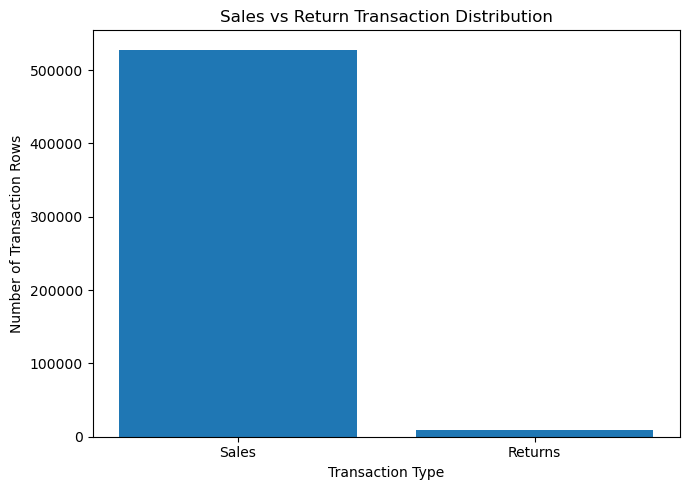

In [21]:
return_distribution = (
    df["Is_Returned"]
    .value_counts()
    .sort_index()
)

return_distribution.index = [
    "Sales",
    "Returns"
]

plt.figure(figsize=(7, 5))

plt.bar(
    return_distribution.index,
    return_distribution.values
)

plt.xlabel("Transaction Type")

plt.ylabel("Number of Transaction Rows")

plt.title("Sales vs Return Transaction Distribution")

plt.tight_layout()

plt.show()

In [24]:
sales_df = df[
    (df["Is_Returned"] == 0)
    & (df["Date"].notna())
].copy()

sales_df["Month"] = (
    sales_df["Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sales = (
    sales_df.groupby("Month")["Transaction_Value"]
    .sum()
    .reset_index()
)

monthly_sales


,Month,Transaction_Value
0,2018-12,4415415.52
1,2019-01,4559856.37
2,2019-02,3335017.18
3,2019-03,4398401.60
4,2019-04,3589497.88
5,2019-05,4578965.08
6,2019-06,4494730.81
7,2019-07,4593867.06
8,2019-08,4758356.02
9,2019-09,6628303.06


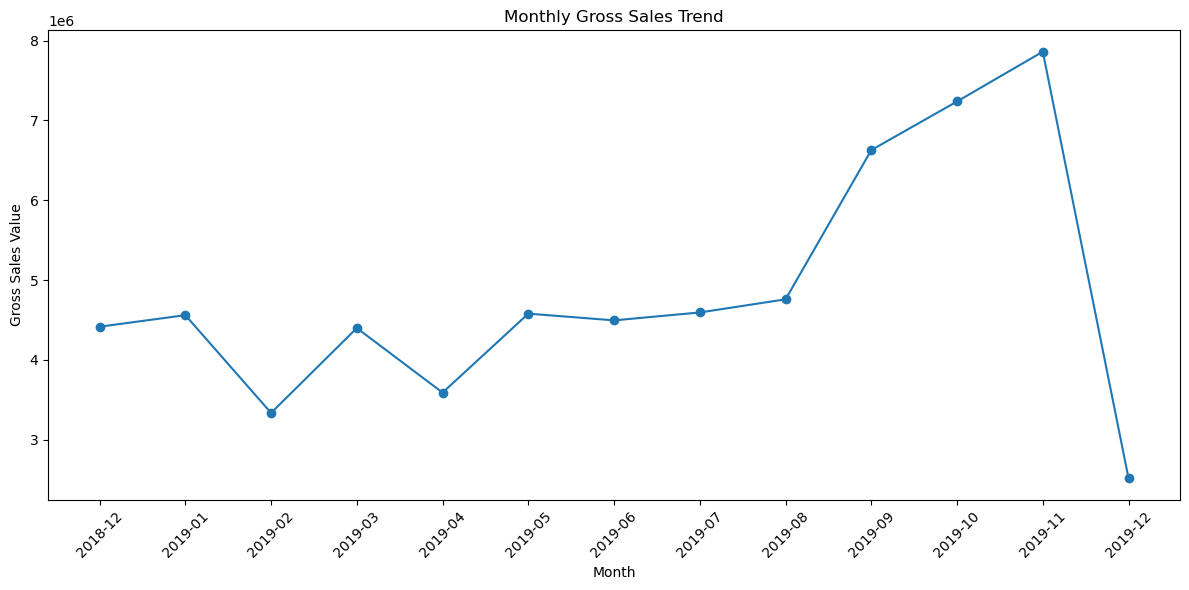

In [25]:


plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Transaction_Value"],
    marker="o"
)

plt.xlabel("Month")

plt.ylabel("Gross Sales Value")

plt.title("Monthly Gross Sales Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [26]:
top_products = (
    sales_df.groupby(
        "ProductName",
        as_index=False
    )["Transaction_Value"]
    .sum()
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .head(10)
)

top_products

,ProductName,Transaction_Value
2203,Paper Craft Little Birdie,1002718.10
1887,Medium Ceramic Top Storage Jar,881990.18
2481,Popcorn Holder,587433.94
3670,World War 2 Gliders Asstd Designs,569735.39
825,Cream Hanging Heart T-Light Holder,484592.69
203,Assorted Colour Bird Ornament,421318.74
2157,Pack Of 72 Retrospot Cake Cases,391485.03
2540,Rabbit Night Light,329029.89
2652,Regency Cakestand 3 Tier,307483.85
1672,Jumbo Bag Red Retrospot,297205.04


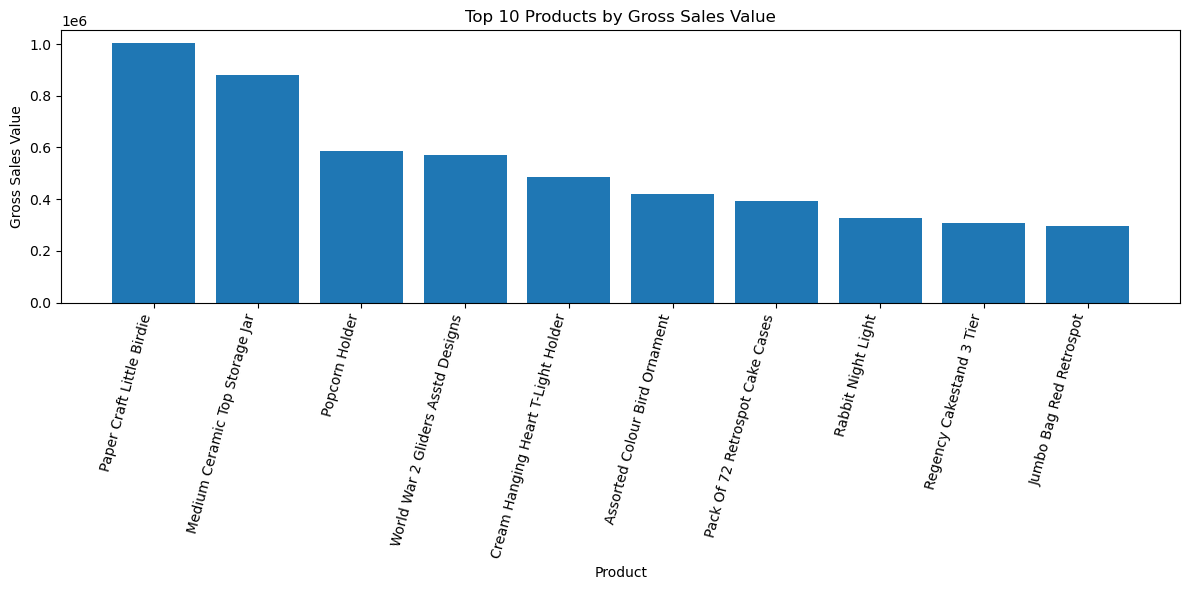

In [27]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_products["ProductName"],
    top_products["Transaction_Value"]
)

plt.xlabel("Product")

plt.ylabel("Gross Sales Value")

plt.title("Top 10 Products by Gross Sales Value")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()

plt.show()

In [28]:
customer_sales = (
    sales_df.dropna(
        subset=["CustomerNo"]
    )
    .groupby(
        "CustomerNo",
        as_index=False
    )["Transaction_Value"]
    .sum()
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .head(10)
)

customer_sales

,CustomerNo,Transaction_Value
1880,14646,2112282.03
3302,16446,1002741.57
2085,14911,914633.52
126,12415,900545.54
4581,18102,897137.36
4082,17450,891438.53
68,12346,840113.80
1506,14156,694965.02
1140,13694,646116.78
4127,17511,639006.19


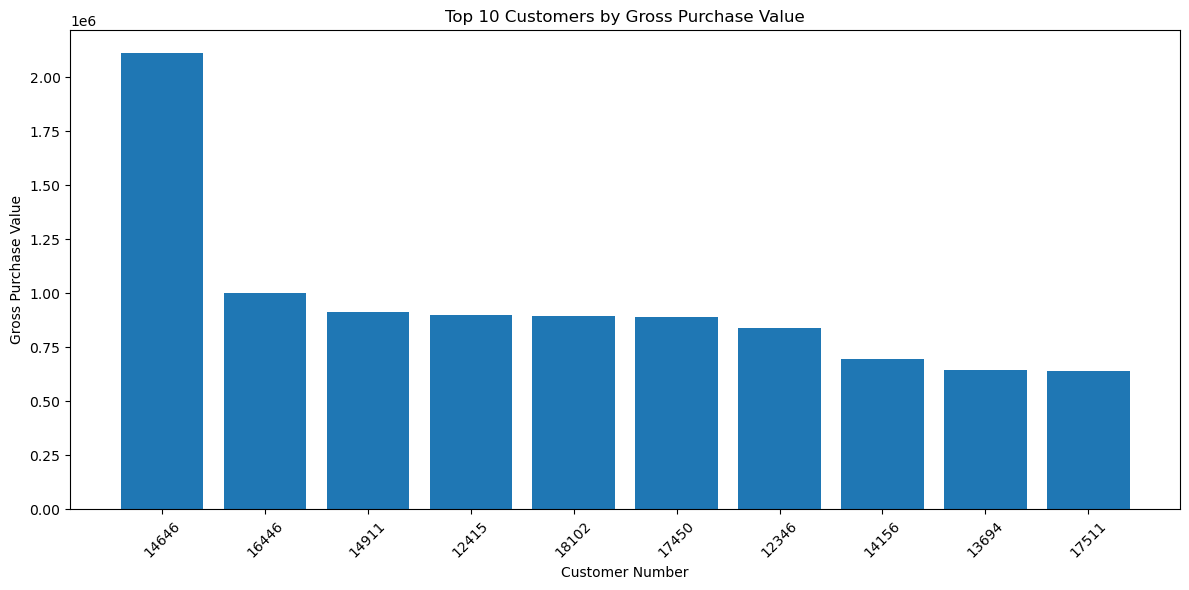

In [29]:
plt.figure(figsize=(12, 6))

plt.bar(
    customer_sales["CustomerNo"].astype(str),
    customer_sales["Transaction_Value"]
)

plt.xlabel("Customer Number")

plt.ylabel("Gross Purchase Value")

plt.title("Top 10 Customers by Gross Purchase Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [30]:
country_sales = (
    sales_df.groupby(
        "Country",
        as_index=False
    )["Transaction_Value"]
    .sum()
    .sort_values(
        "Transaction_Value",
        ascending=False
    )
    .head(10)
)

country_sales

,Country,Transaction_Value
36,United Kingdom,52524658.47
24,Netherlands,2151553.59
10,EIRE,1713410.95
14,Germany,1371543.27
13,France,1330652.89
0,Australia,995607.91
32,Sweden,401879.89
33,Switzerland,361969.25
20,Japan,293155.44
31,Spain,281012.27


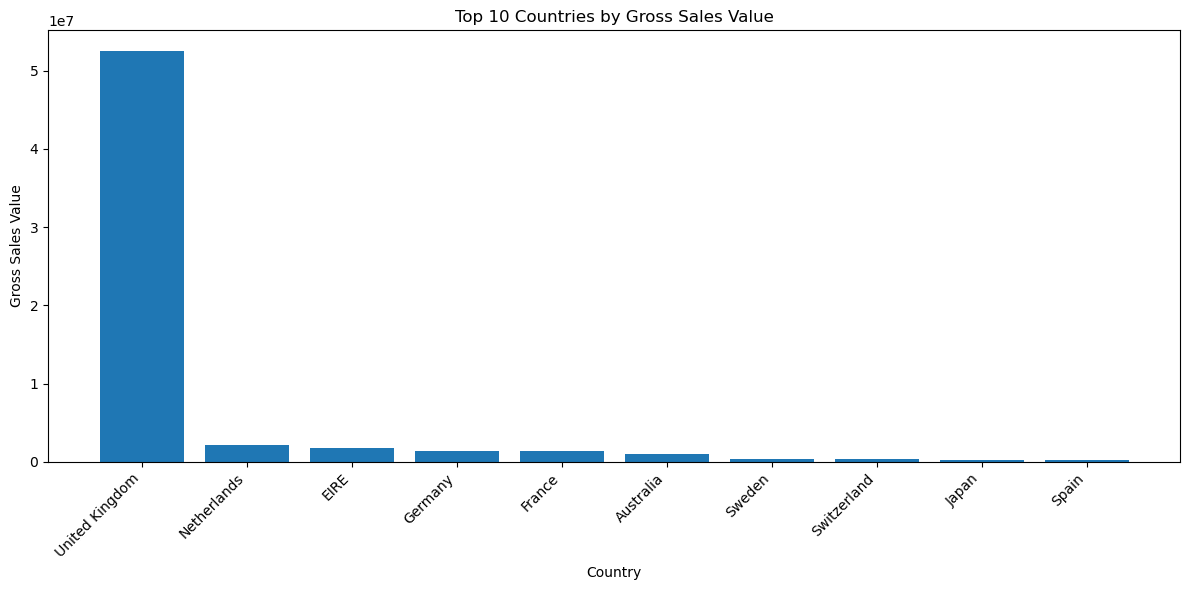

In [31]:
plt.figure(figsize=(12, 6))

plt.bar(
    country_sales["Country"],
    country_sales["Transaction_Value"]
)

plt.xlabel("Country")

plt.ylabel("Gross Sales Value")

plt.title("Top 10 Countries by Gross Sales Value")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [32]:
country_returns = (
    df.groupby("Country")
    .agg(
        Total_Transactions=("TransactionNo", "count"),
        Returned_Transactions=("Is_Returned", "sum"),
        Return_Rate=("Is_Returned", "mean")
    )
    .reset_index()
)

country_returns["Return_Rate_Percentage"] = (
    country_returns["Return_Rate"] * 100
)

reliable_country_returns = (
    country_returns[
        country_returns["Total_Transactions"] >= 100
    ]
    .sort_values(
        "Return_Rate_Percentage",
        ascending=False
    )
    .head(10)
)

reliable_country_returns

,Country,Total_Transactions,Returned_Transactions,Return_Rate,Return_Rate_Percentage
34,USA,379,112,0.295515,29.551451
23,Malta,149,14,0.093960,9.395973
20,Japan,371,34,0.091644,9.164420
19,Italy,661,37,0.055976,5.597579
0,Australia,1704,73,0.042840,4.284038
14,Germany,10675,435,0.040749,4.074941
10,EIRE,8048,241,0.029945,2.994533
32,Sweden,417,9,0.021583,2.158273
9,Denmark,416,8,0.019231,1.923077
31,Spain,2430,44,0.018107,1.810700


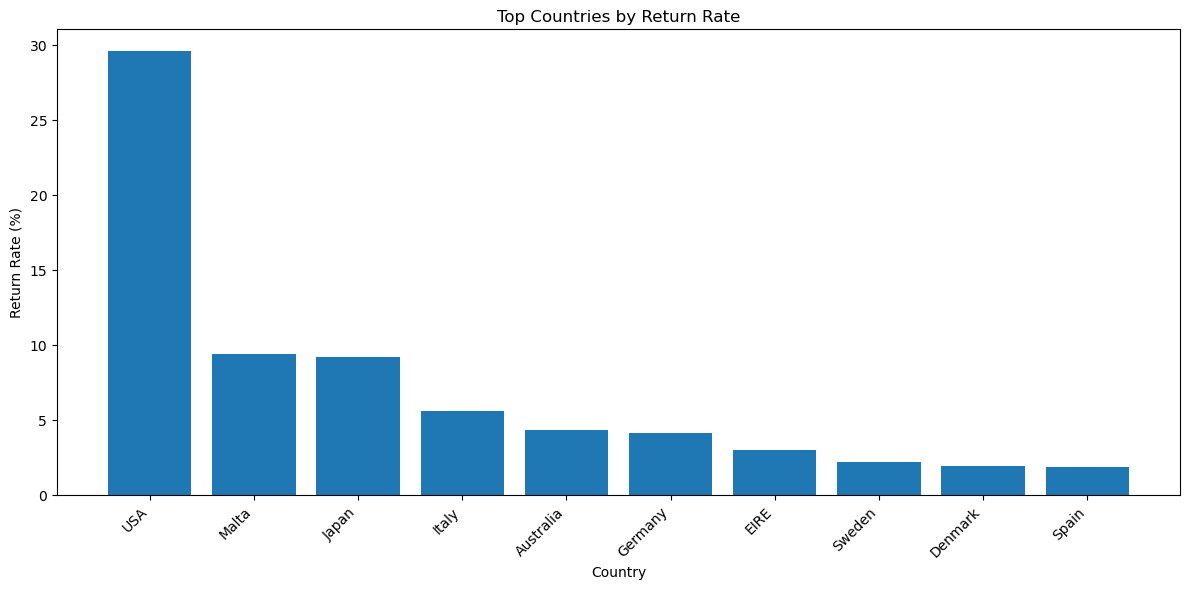

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_country_returns["Country"],
    reliable_country_returns["Return_Rate_Percentage"]
)

plt.xlabel("Country")

plt.ylabel("Return Rate (%)")

plt.title("Top Countries by Return Rate")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

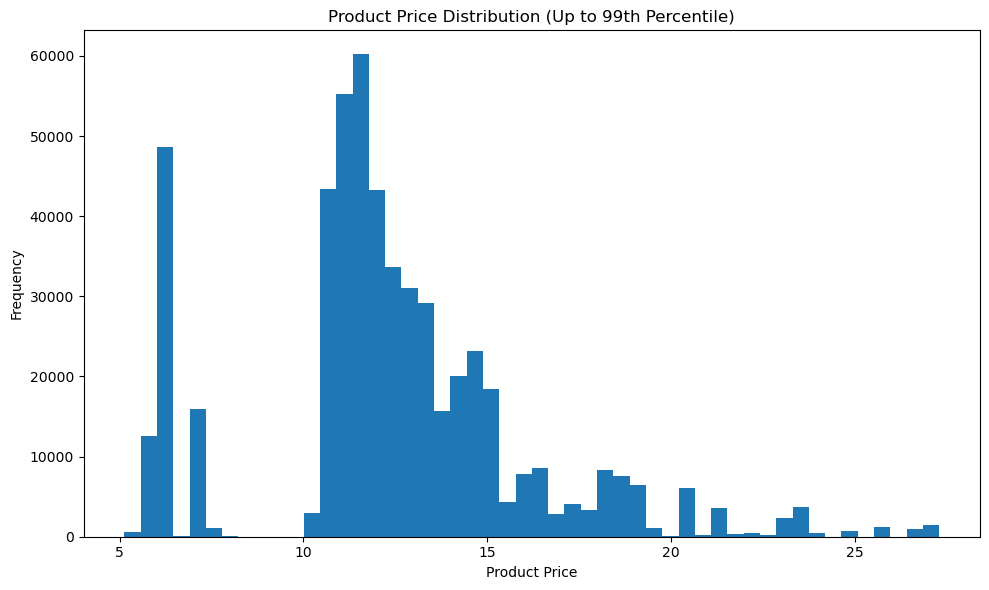

In [34]:
price_limit = df["Price"].quantile(0.99)

price_data = df[
    (df["Price"] > 0)
    & (df["Price"] <= price_limit)
]["Price"]

plt.figure(figsize=(10, 6))

plt.hist(
    price_data,
    bins=50
)

plt.xlabel("Product Price")

plt.ylabel("Frequency")

plt.title("Product Price Distribution (Up to 99th Percentile)")

plt.tight_layout()

plt.show()

In [35]:
positive_price_df = df[
    df["Price"] > 0
].copy()

positive_price_df["Price_Range"] = pd.cut(
    positive_price_df["Price"],
    bins=[
        0,
        5,
        10,
        20,
        50,
        100,
        float("inf")
    ],
    labels=[
        "0-5",
        "5-10",
        "10-20",
        "20-50",
        "50-100",
        "100+"
    ],
    right=False
)

price_return_analysis = (
    positive_price_df.groupby(
        "Price_Range",
        observed=False
    )
    .agg(
        Total_Transactions=("TransactionNo", "count"),
        Returned_Transactions=("Is_Returned", "sum"),
        Return_Rate=("Is_Returned", "mean")
    )
    .reset_index()
)

price_return_analysis["Return_Rate_Percentage"] = (
    price_return_analysis["Return_Rate"] * 100
)

price_return_analysis

,Price_Range,Total_Transactions,Returned_Transactions,Return_Rate,Return_Rate_Percentage
0,0-5,0,0,NaN,NaN
1,5-10,79085,1004,0.012695,1.269520
2,10-20,431139,6706,0.015554,1.555415
3,20-50,25694,831,0.032342,3.234218
4,50-100,296,26,0.087838,8.783784
5,100+,136,18,0.132353,13.235294


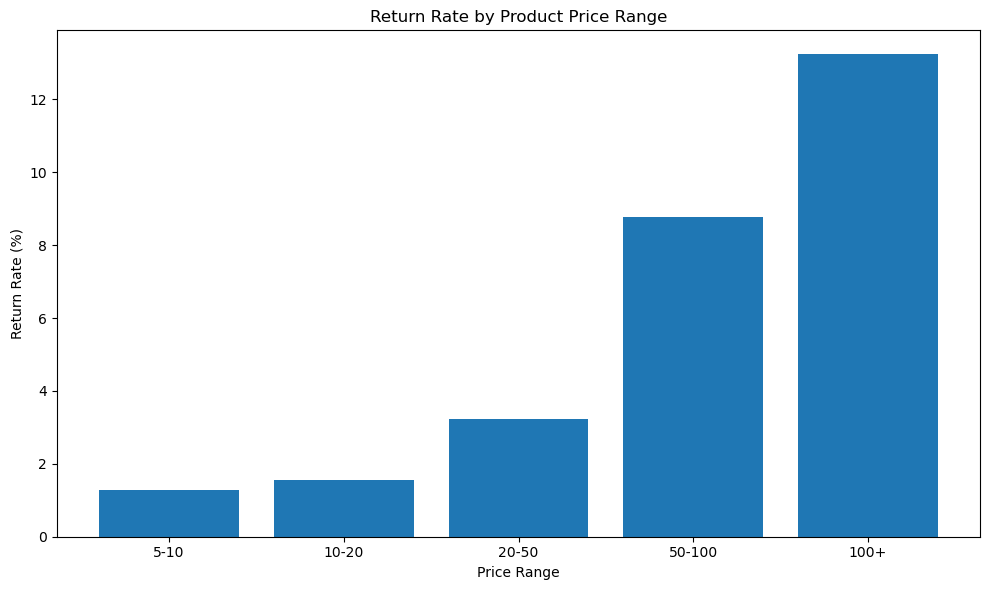

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    price_return_analysis["Price_Range"].astype(str),
    price_return_analysis["Return_Rate_Percentage"]
)

plt.xlabel("Price Range")

plt.ylabel("Return Rate (%)")

plt.title("Return Rate by Product Price Range")

plt.tight_layout()

plt.show()

In [37]:
returned_df = df[
    df["Is_Returned"] == 1
].copy()

top_returned_products = (
    returned_df.groupby(
        "ProductName",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Returned_Transactions"
        }
    )
    .sort_values(
        "Returned_Transactions",
        ascending=False
    )
    .head(10)
)

top_returned_products

,ProductName,Returned_Transactions
1356,Regency Cakestand 3 Tier,181
862,Jam Making Set With Jars,87
1486,Set Of 3 Cake Tins Pantry Design,74
1657,Strawberry Ceramic Trinket Pot,61
1411,Roses Regency Teacup And Saucer,54
1258,Popcorn Holder,50
1282,Recipe Box Pantry Yellow Design,47
1851,Wood 2 Drawer Cabinet White Finish,45
882,Jumbo Bag Red Retrospot,44
1320,Red Retrospot Cake Stand,42


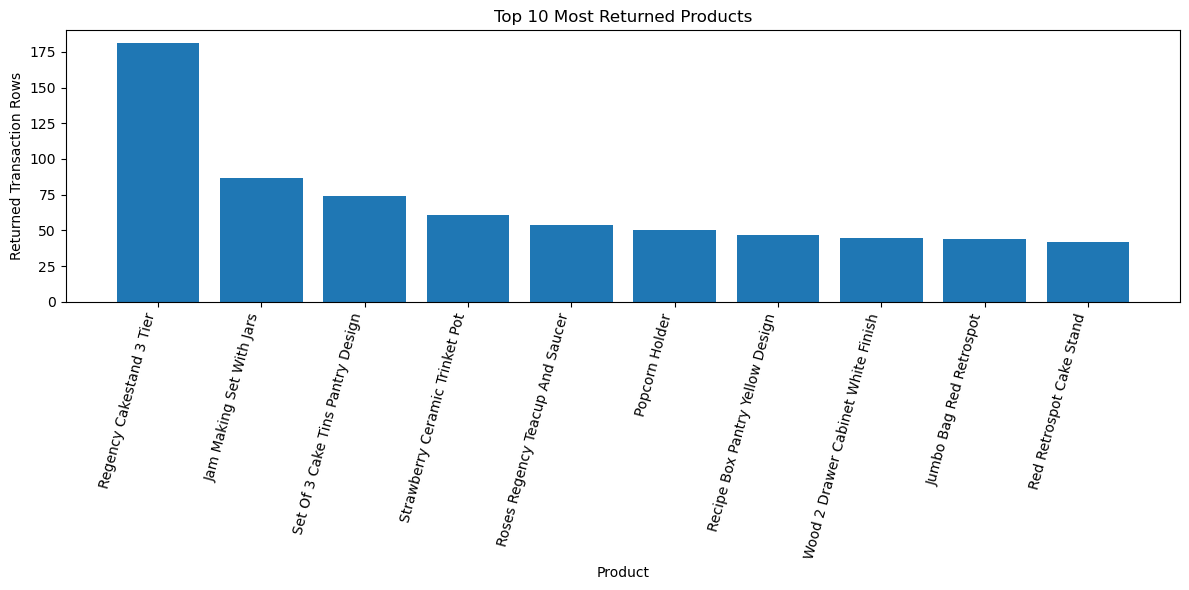

In [38]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_returned_products["ProductName"],
    top_returned_products["Returned_Transactions"]
)

plt.xlabel("Product")

plt.ylabel("Returned Transaction Rows")

plt.title("Top 10 Most Returned Products")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()

plt.show()

In [39]:
output_folder = r"C:\Users\91934\OneDrive\Desktop\DA\PROJECT\docs"

monthly_sales.to_csv(
    output_folder + r"\monthly_sales.csv",
    index=False
)

top_products.to_csv(
    output_folder + r"\top_products.csv",
    index=False
)

customer_sales.to_csv(
    output_folder + r"\top_customers.csv",
    index=False
)

country_returns.to_csv(
    output_folder + r"\country_return_rates.csv",
    index=False
)

price_return_analysis.to_csv(
    output_folder + r"\price_return_analysis.csv",
    index=False
)

top_returned_products.to_csv(
    output_folder + r"\top_returned_products.csv",
    index=False
)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


## Day 12 EDA Findings

- The dataset was profiled for missing values, duplicate records, data types, and invalid dates.
- Cancelled or returned transactions were identified using TransactionNo values starting with "C".
- Monthly gross sales trends were analyzed using completed sales transactions.
- Top products, customers, and countries were identified based on gross sales value.
- Country-level return rates were analyzed using a minimum transaction threshold to reduce misleading results from small samples.
- Product price distributions and return rates across different price ranges were analyzed.
- Products with the highest number of returned transaction rows were identified.
- The refined EDA notebook provides summary tables and visualizations that can be used for further business analysis and dashboard development.